In [ ]:
!pip install seaborn torch xgboost scikit-learn pandas numpy matplotlib

 Çalışma Ortamı: cpu
 Dosya okunuyor...
   Orijinal Veri Boyutu: (4599270, 9)
   Çalışılacak Veri Boyutu: (137978, 9)

 Veri Analizi Grafiği Çiziliyor...


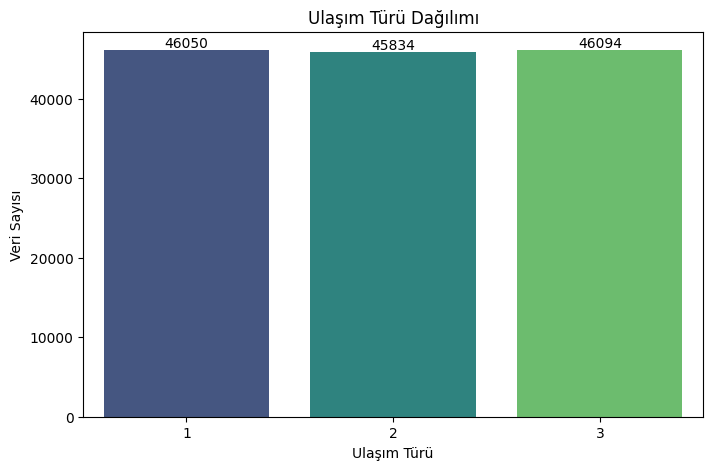

Şekil 1. vehicle_type sınıf dağılımı

 Veri ön işleme yapılıyor...
 Ön işleme tamam.

 Model 1: Ensemble (Voting & Stacking) Başlıyor...
   ⏳ Voting (Ensemble) eğitiliyor...
   ⏳ Stacking (Ensemble) eğitiliyor...

 Model 2: PyTorch MLP Başlıyor...
   Epoch 1/5 tamamlandı.
   Epoch 2/5 tamamlandı.
   Epoch 3/5 tamamlandı.
   Epoch 4/5 tamamlandı.
   Epoch 5/5 tamamlandı.

 GENEL SONUÇLAR
                     Accuracy  F1-Score    Recall
Model                                            
Voting (Ensemble)    0.601573  0.639189  0.712280
Stacking (Ensemble)  0.608965  0.642339  0.708696
PyTorch MLP          0.612553  0.661367  0.763622

 ULAŞIM TÜRÜNE GÖRE PERFORMANS ANALİZİ

 Kırılım Tablosu:
                 Model   Ulaşım Türü  Accuracy  F1-Score
0    Voting (Ensemble)      Karayolu  0.556007  0.567825
1    Voting (Ensemble)  Raylı Sistem  0.652622  0.689425
2    Voting (Ensemble)    Deniz Yolu  0.596203  0.653424
3  Stacking (Ensemble)      Karayolu  0.552273  0.562882
4  Stacking (Ens

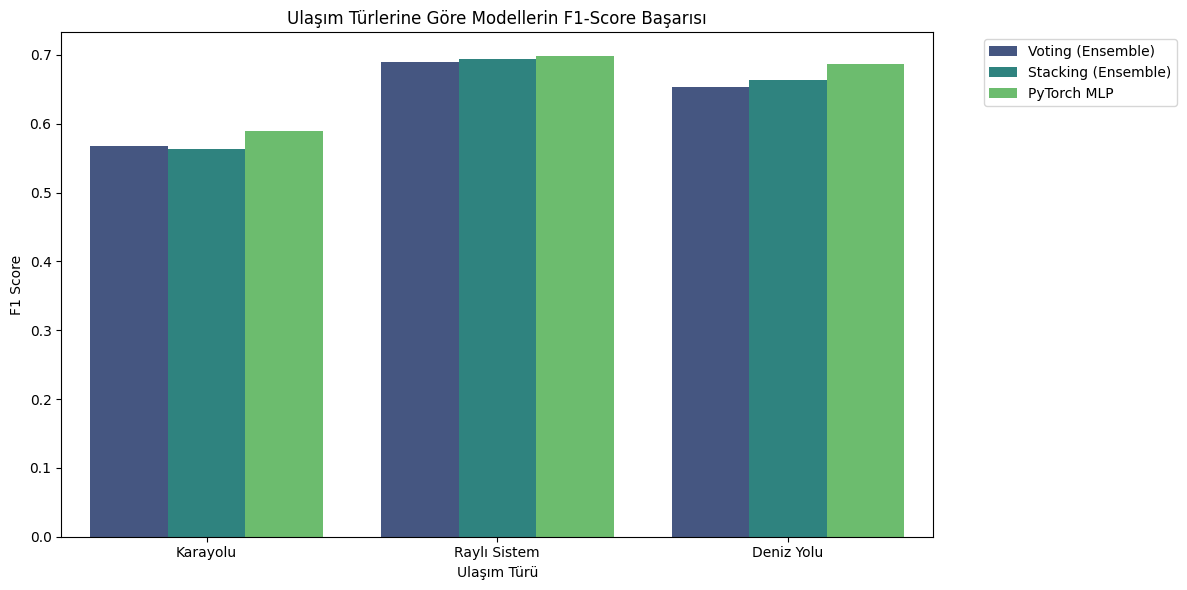

TÜM ANALİZLER TAMAMLANDI!


In [9]:
# =====================================================
# İSTANBUL ULAŞIM PROJESİ - FİNAL YUSUF DEMİRHAN PROJE
# =====================================================


try:
    import xgboost
    import seaborn
except ImportError:
    print("Kütüphaneler yükleniyor, lütfen bekleyin...")
    !pip install seaborn torch xgboost scikit-learn pandas numpy matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble선을 (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.cuda.is_available() else "cpu")
print(f" Çalışma Ortamı: {device}")

# 1.Verilerin yüklenmesi ve işlendiği kısımlar.

print(" Dosya okunuyor...")
try:
    df = pd.read_csv(file_path) # Changed to use the 'file_path' variable
    print(f"   Orijinal Veri Boyutu: {df.shape}")


    df = df.sample(frac=0.03, random_state=42)
    print(f"   Çalışılacak Veri Boyutu: {df.shape}")

except FileNotFoundError:
    print(f"HATA: '{file_path}' bulunamadı. Lütfen dosya yolunu kontrol edin.") # Updated error message
    df = pd.DataFrame()

if not df.empty:

    # GRAFİK: ROAD_TYPE Sınıfının dağılımı yapılıyor

    print("\n Veri Analizi Grafiği Çiziliyor...")
    plt.figure(figsize=(8, 5))

    # Görselleştirme için road_type kullandım
    col_to_plot = "road_type" if "road_type" in df.columns else "vehicle_type"

    ax = sns.countplot(data=df, x=col_to_plot, palette="viridis")
    plt.title("Ulaşım Türü Dağılımı")
    plt.xlabel("Ulaşım Türü")
    plt.ylabel("Veri Sayısı")
    for container in ax.containers:
        ax.bar_label(container)
    plt.show()
    print(f"Şekil 1. {col_to_plot} sınıf dağılımı\n")

    # Ön işleme ayarları, passenger sayısı ve saatlere göre durum ayarlamak için.
    X = df.drop("is_peak_hour", axis=1)
    y = df["is_peak_hour"]


    num_cols = ["passenger_count", "mean_passenger_by_route_hour"]


    #Vehicle typeların kategorik olarak işlenmesi.
    cat_cols = ["district", "route_code", "vehicle_type"]

    preprocess = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    print(" Veri ön işleme yapılıyor...")
    X_train_processed = preprocess.fit_transform(X_train)
    X_test_processed = preprocess.transform(X_test)
    print(" Ön işleme tamam.")

    # 2. Ensemble Modelleri

    print("\n Model 1: Ensemble (Voting & Stacking) Başlıyor...")

    rf = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
    gb = GradientBoostingClassifier(n_estimators=30, learning_rate=0.1, max_depth=3)
    xgb = XGBClassifier(
        n_estimators=50, max_depth=4, learning_rate=0.1,
        eval_metric="logloss", n_jobs=-1, random_state=42
    )

    voting_clf = VotingClassifier(
        estimators=[("rf", rf), ("gb", gb), ("xgb", xgb)],
        voting="soft"
    )

    stacking_clf = StackingClassifier(
        estimators=[("rf", rf), ("xgb", xgb)],
        final_estimator=LogisticRegression(),
        cv=2,
        n_jobs=-1
    )

    sklearn_models = {
        "Voting (Ensemble)": voting_clf,
        "Stacking (Ensemble)": stacking_clf
    }

    results = []

    for name, model in sklearn_models.items():
        print(f"   ⏳ {name} eğitiliyor...")
        model.fit(X_train_processed, y_train)
        preds = model.predict(X_test_processed)
        probs = model.predict_proba(X_test_processed)[:, 1]

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, preds),
            "F1-Score": f1_score(y_test, preds),
            "Recall": recall_score(y_test, preds),
            "Preds": preds,
            "Probs": probs
        })

    # 3. PYTORCH MLP

    print("\n Model 2: PyTorch MLP Başlıyor...")

    class TransportDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.FloatTensor(X)
            self.y = torch.FloatTensor(y.values).reshape(-1, 1)
        def __len__(self): return len(self.X)
        def __getitem__(self, idx): return self.X[idx], self.y[idx]

    batch_size = 128
    train_loader = DataLoader(TransportDataset(X_train_processed, y_train), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TransportDataset(X_test_processed, y_test), batch_size=batch_size, shuffle=False)

    class TransportMLP(nn.Module):
        def __init__(self, input_dim):
            super(TransportMLP, self).__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 1)
            )
        def forward(self, x):
            return self.net(x)

    model = TransportMLP(X_train_processed.shape[1]).to(device)

    # Class Weight
    pos_weight = torch.tensor([(y_train==0).sum() / (y_train==1).sum()]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    for epoch in range(5):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
        print(f"   Epoch {epoch+1}/5 tamamlandı.")

    model.eval()
    all_preds, all_probs = [], []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            outputs = torch.sigmoid(model(X_batch.to(device)))
            all_probs.extend(outputs.cpu().numpy())
            all_preds.extend((outputs > 0.5).cpu().numpy())

    results.append({
        "Model": "PyTorch MLP",
        "Accuracy": accuracy_score(y_test, all_preds),
        "F1-Score": f1_score(y_test, all_preds),
        "Recall": recall_score(y_test, all_preds),
        "Preds": np.array(all_preds),
        "Probs": np.array(all_probs)
    })

    # 4. GENEL SONUÇLAR

    print("\n GENEL SONUÇLAR")
    res_df = pd.DataFrame(results).set_index("Model")
    print(res_df[["Accuracy", "F1-Score", "Recall"]])

    # 5. ULAŞIM TÜRÜNE GÖRE DETAYLI ANALİZ

    print("\n ULAŞIM TÜRÜNE GÖRE PERFORMANS ANALİZİ")

    breakdown_results = []

    # ID'leri kullanılan verilere işleme ve isimlendirme kısmı.
    # 1: Karayolu (Otobüs), 2: Raylı (Metro), 3: Deniz (Vapur vs.)
    type_map = {1: "Karayolu", 2: "Raylı Sistem", 3: "Deniz Yolu"}

    unique_types = X_test['vehicle_type'].unique()

    for res in results:
        model_name = res["Model"]
        preds = res["Preds"]

        for v_type in unique_types:
            mask = (X_test['vehicle_type'] == v_type).values
            if mask.sum() == 0: continue

            y_subset = y_test[mask]
            p_subset = preds[mask]

            acc = accuracy_score(y_subset, p_subset)
            f1 = f1_score(y_subset, p_subset, zero_division=0)

            # İsimlendirme
            type_name = type_map.get(v_type, str(v_type))

            breakdown_results.append({
                "Model": model_name,
                "Ulaşım Türü": type_name,
                "Accuracy": acc,
                "F1-Score": f1
            })

    breakdown_df = pd.DataFrame(breakdown_results)
    print("\n Kırılım Tablosu:")
    print(breakdown_df)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=breakdown_df, x="Ulaşım Türü", y="F1-Score", hue="Model", palette="viridis")
    plt.title("Ulaşım Türlerine Göre Modellerin F1-Score Başarısı")
    plt.ylabel("F1 Score")
    plt.xlabel("Ulaşım Türü")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    print("TÜM ANALİZLER TAMAMLANDI!")

else:
    print("İşlem durduruldu.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')